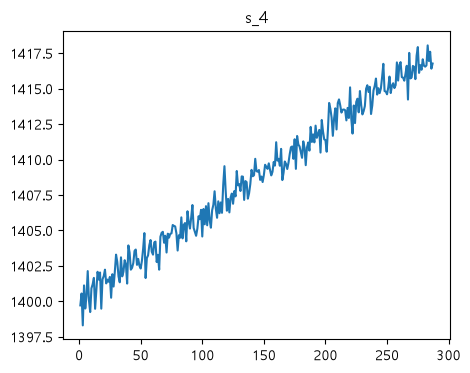

In [ ]:
# 실습 1. 센서 시계열 그려보기

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('.venv/21_cmapss_fd001_sample.csv')

# print(df.shape) # (1031, 10)

engine = df[df['unit_nr'] == 2]
# print(df.shape)
# print(df['s_4'].head(2))
# 0    1399.30
# 1    1401.18

plt.figure(figsize=(5, 4))
plt.title('s_4')
plt.plot(engine['time_cycles'], engine['s_4'])

plt.show()

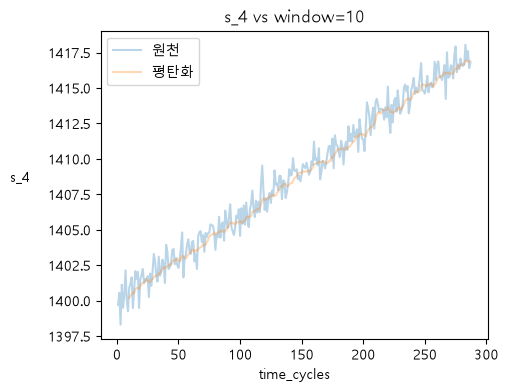

In [25]:
# 실습 2. 이동평균선으로 추세 보기
move10 = engine['s_4'].rolling(window=10).mean()

# print(move10.tail())
# print(move10.isna().sum())

plt.figure(figsize=(5, 4))
plt.title('s_4 vs window=10')
plt.plot(engine['time_cycles'], engine['s_4'], label='원천', alpha=0.3)
plt.plot(engine['time_cycles'], move10, label='평탄화', alpha=0.3)
plt.xlabel('time_cycles')
plt.ylabel('s_4', rotation=0, labelpad=20)
plt.legend()
plt.show()


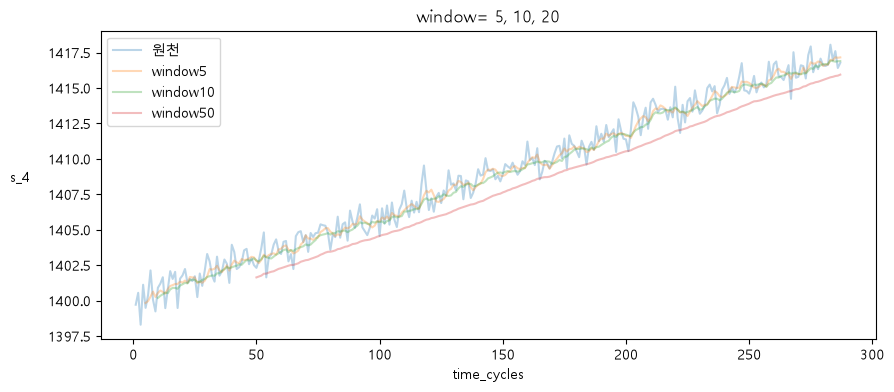

In [ ]:
# 실습 3. 윈도우 크기 바꿔 비교하기

move5 = engine['s_4'].rolling(window=5).mean()
move10 = engine['s_4'].rolling(window=10).mean()
move50 = engine['s_4'].rolling(window=50).mean()


plt.figure(figsize=(10, 4))
plt.title('window= 5, 10, 20')
plt.plot(engine['time_cycles'], engine['s_4'], label='원천', alpha=0.3)
plt.plot(engine['time_cycles'], move5, label='window5', alpha=0.3)
plt.plot(engine['time_cycles'], move10, label='window10', alpha=0.3)
plt.plot(engine['time_cycles'], move50, label='window50', alpha=0.3)
plt.xlabel('time_cycles')
plt.ylabel('s_4', rotation=0, labelpad=20)
plt.legend()
plt.show()


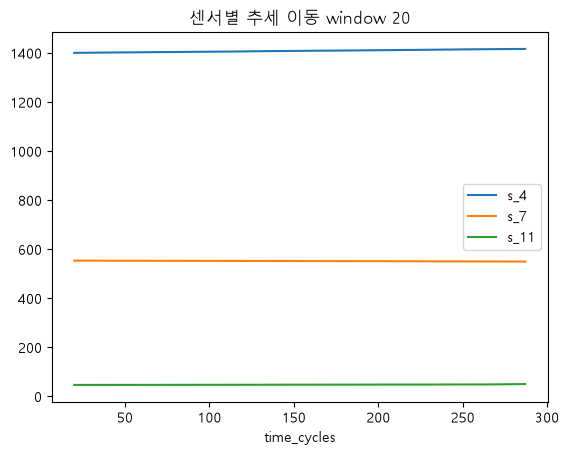

In [30]:
# 실습 4. 여러 센서 추세 방향 비교

sensors = ['s_4', 's_7', 's_11']
plt.title('센서별 추세 이동 window 20')
for sensor in sensors:
    move20 = engine[sensor].rolling(window=20).mean()
    plt.plot(engine['time_cycles'], move20, label=sensor)
plt.xlabel('time_cycles')
plt.legend()
plt.show()


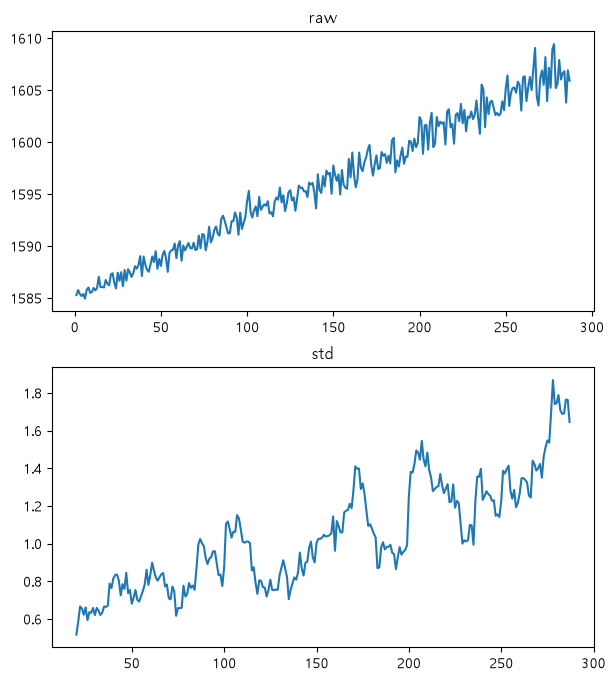

In [35]:
# 실습 5. 이동표준편차로 변동성 구간 찾기
std20 = engine['s_3'].rolling(20).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7,8))
ax1.set_title('raw')
ax1.plot(engine['time_cycles'], engine['s_3'])

ax2.set_title('std')
ax2.plot(engine['time_cycles'], std20)

plt.tight_layout
plt.show()

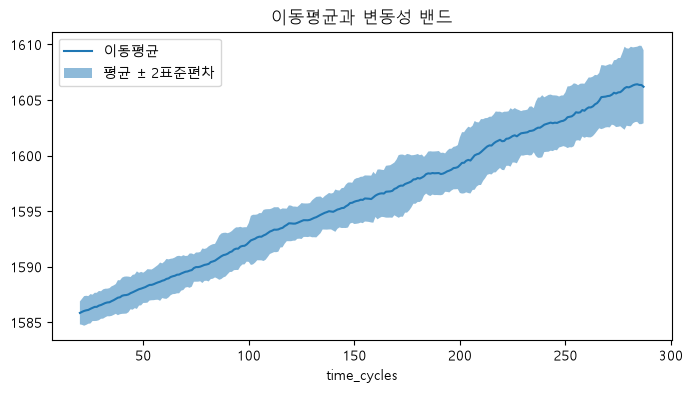

In [ ]:
# 실습 6. 평균과 변동성 밴드 함께 그리기
ma = engine['s_3'].rolling(20).mean()
std = engine['s_3'].rolling(20).std()

top = ma + (2 * std)
bottom = ma - (2 * std)

plt.figure(figsize=(8, 4))
plt.title('이동평균과 변동성 밴드')

plt.plot(engine['time_cycles'], ma, label='이동평균')

plt.fill_between(
    engine['time_cycles'],
    bottom,
    top,
    alpha=0.5,
    label='평균 ± 2표준편차'
)

plt.xlabel('time_cycles')
plt.legend()
plt.show()

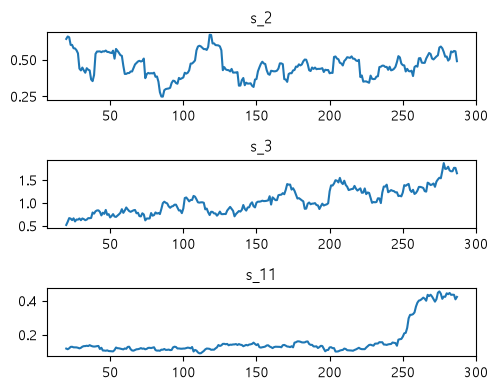

In [47]:
# 실습 7. 변동성 패턴 해석
sensors = ['s_2', 's_3', 's_11']

fig, axs = plt.subplots(3, 1, figsize=(5,4))

for ax, sensor in zip(axs, sensors):
    ax.set_title(sensor)
    std20 = engine[sensor].rolling(20).std()
    ax.plot(engine['time_cycles'], std20, label=sensor)

plt.tight_layout()
plt.show()